# Cardiac Patient Monitoring System

    This Notebook explores the dataset of 50000 patient records to understand the factors associated with heart disease. It combines demographic information (Age, Gender), body measurements(Height, Weight, BMI), lifestyle and behavioural factors(Smoking, Physical_Activity,Alchohol_Intake, Diet, Stress_Level), diagnosed medical conditions (Diabetes, Hyperlipidemia, Family_History, Previous_Heart_Attack) and clinical measurements (Systolic_BP, Diastolic_BP, Heart_Rate, Blood_Sugar_Fasting, Cholesterol_Total).

    The purpose of this analysis is to understand the data structure and quality, reveal strongly correlated factors with heart disease and use these insights as a future reference to guide feature engineering, model building and evaluation.

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs("outputs", exist_ok=True)

In [68]:
df = pd.read_csv("synthetic_heart_disease_dataset.csv")
df

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,74,Male,104,155,29.9,Current,NaN,Active,Average,Medium,...,0,0,0,0,127,80,83,174,248,1
49996,53,Male,95,163,35.8,Never,Low,Moderate,Healthy,Low,...,0,1,0,0,141,96,70,148,252,0
49997,38,Female,91,197,32.3,Former,Low,Moderate,Unhealthy,Low,...,0,0,0,0,178,94,90,75,235,0
49998,68,Male,115,152,18.6,Never,High,Moderate,Average,Medium,...,0,0,0,0,118,110,106,113,177,0


In [69]:
df.shape

(50000, 21)

In [70]:
df.dtypes

Age                        int64
Gender                    object
Weight                     int64
Height                     int64
BMI                      float64
Smoking                   object
Alcohol_Intake            object
Physical_Activity         object
Diet                      object
Stress_Level              object
Hypertension               int64
Diabetes                   int64
Hyperlipidemia             int64
Family_History             int64
Previous_Heart_Attack      int64
Systolic_BP                int64
Diastolic_BP               int64
Heart_Rate                 int64
Blood_Sugar_Fasting        int64
Cholesterol_Total          int64
Heart_Disease              int64
dtype: object

In [71]:
df.columns

Index(['Age', 'Gender', 'Weight', 'Height', 'BMI', 'Smoking', 'Alcohol_Intake',
       'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes',
       'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting',
       'Cholesterol_Total', 'Heart_Disease'],
      dtype='object')

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         29891 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-null  object 
 9   Stress_Level           50000 non-null  object 
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int64  
 15  Sy

In [73]:
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [74]:
missing = df.isnull().sum()
missing_prcnt = (missing/len(df))*100
missing_df = pd.DataFrame({"Missing Values": missing, "Percentage":missing_prcnt})
missing_df = missing_df[missing_df["Missing Values"]>0]
missing_df

,Missing Values,Percentage
Alcohol_Intake,20109,40.218


In [75]:
df.duplicated().sum()

np.int64(0)

    The dataset contains 50000 rows and 21 columns ( 20 - features, 1 - target). After examining the dataset, no duplicate rows were found. The only column with missing data is the Alchohol_Intake with 40% of its values missing. 

    9 Numeric columns exist (e.g. Age, Weight, Height, BMI, Hypertension).6/12 categorical columns store data as binary (0/1) information and were treated as categoricals throughout the analysis rather than being summarized with numerical statistics.

## Descripive Statistics

In [76]:
categ_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist() 
low_cardinality_numeric = [col for col in df.select_dtypes(include=['int64','float64']).columns 
                           if df[col].nunique() <= 5]

categ_cols = categ_cols + low_cardinality_numeric



In [77]:
df.describe()

,Age,Weight,Height,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.46406,84.547520,174.460000,28.984284,0.299620,0.199260,0.251660,0.400500,0.099280,139.299580,89.528800,84.449560,124.493020,224.556360,0.463460
std,14.43809,20.213257,14.420379,6.367494,0.458096,0.399448,0.433971,0.490005,0.299041,23.083544,17.258063,14.491325,31.691507,43.157467,0.498668
min,30.00000,50.000000,150.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,60.000000,60.000000,70.000000,150.000000,0.000000
25%,42.00000,67.000000,162.000000,23.500000,0.000000,0.000000,0.000000,0.000000,0.000000,119.000000,75.000000,72.000000,97.000000,187.000000,0.000000
50%,54.00000,85.000000,174.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.000000,90.000000,85.000000,125.000000,225.000000,0.000000
75%,67.00000,102.000000,187.000000,34.500000,1.000000,0.000000,1.000000,1.000000,0.000000,159.000000,104.000000,97.000000,152.000000,262.000000,1.000000
max,79.00000,119.000000,199.000000,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,109.000000,179.000000,299.000000,1.000000


In [78]:
for col in categ_cols:
    print(df[col].value_counts(normalize=True)*100)

Gender
Female    50.22
Male      49.78
Name: proportion, dtype: float64
Smoking
Never      60.32
Current    19.93
Former     19.75
Name: proportion, dtype: float64
Alcohol_Intake
Low         49.891272
Moderate    33.103610
High        17.005119
Name: proportion, dtype: float64
Physical_Activity
Moderate     49.952
Sedentary    30.154
Active       19.894
Name: proportion, dtype: float64
Diet
Average      50.338
Healthy      29.950
Unhealthy    19.712
Name: proportion, dtype: float64
Stress_Level
Medium    40.266
Low       39.882
High      19.852
Name: proportion, dtype: float64
Hypertension
0    70.038
1    29.962
Name: proportion, dtype: float64
Diabetes
0    80.074
1    19.926
Name: proportion, dtype: float64
Hyperlipidemia
0    74.834
1    25.166
Name: proportion, dtype: float64
Family_History
0    59.95
1    40.05
Name: proportion, dtype: float64
Previous_Heart_Attack
0    90.072
1     9.928
Name: proportion, dtype: float64
Heart_Disease
0    53.654
1    46.346
Name: proportion, dty

In [79]:
print("Number of unique values per column:")
for col in categ_cols:
    print(col, df[col].nunique())

Number of unique values per column:
Gender 2
Smoking 3
Alcohol_Intake 3
Physical_Activity 3
Diet 3
Stress_Level 3
Hypertension 2
Diabetes 2
Hyperlipidemia 2
Family_History 2
Previous_Heart_Attack 2
Heart_Disease 2


In [80]:
#revise
numeric_cols = [col for col in df.select_dtypes(include=['int64','float64']).columns 
                           if df[col].nunique() > 5]
print("Numeric data skew:")
skew = df[numeric_cols].skew().sort_values(ascending=False)
skew

Numeric data skew:


Age                    0.007914
Systolic_BP            0.004836
Blood_Sugar_Fasting    0.002327
Heart_Rate             0.001207
BMI                    0.001204
Height                -0.000252
Weight                -0.003408
Diastolic_BP          -0.003883
Cholesterol_Total     -0.006060
dtype: float64

    The target variable [Heart Disease] is reasonably balanced, with 53.7% of the patients labeled as heart disease free (0) and 46.3% labeled as heart disease patients (1). These statistics verify that there is no class imbalance and accuracy can be regarded as a meaningful evaluation metric later on. No calss_weighting proceedures are necessary for the dataset.

## EDA

### Univariate Analysis

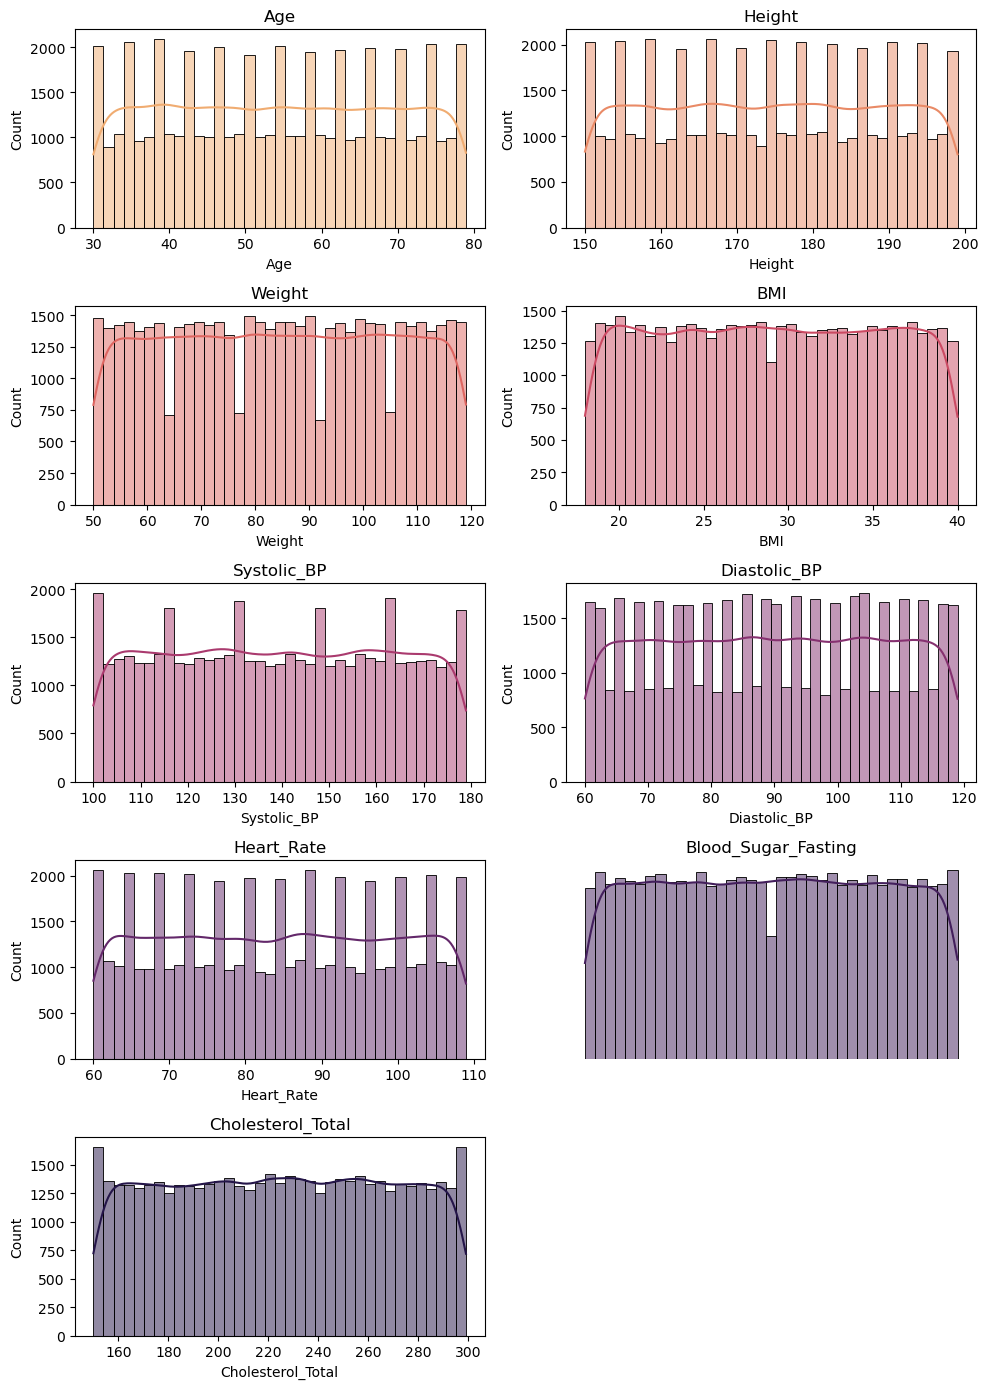

In [81]:
fig , axes = plt.subplots(5,2, figsize=(10,14))
col = ["Age", "Height", "Weight", "BMI", "Systolic_BP", "Diastolic_BP", "Heart_Rate", "Blood_Sugar_Fasting", "Cholesterol_Total"]
colors = ["#f0ac71", "#e98a66", "#de6661", "#cb4a63", "#aa3a6e", "#863170", "#63286a","#431f5c","#241549"]
axes = axes.flatten()

for i, col in enumerate(col):
    sns.histplot(df[col], kde= True, ax=axes[i], color=colors[i])
    axes[i].set_title(col)

axes[-1].axis('off')
axes[7].axis('off')
plt.tight_layout()
plt.savefig("outputs/univar_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

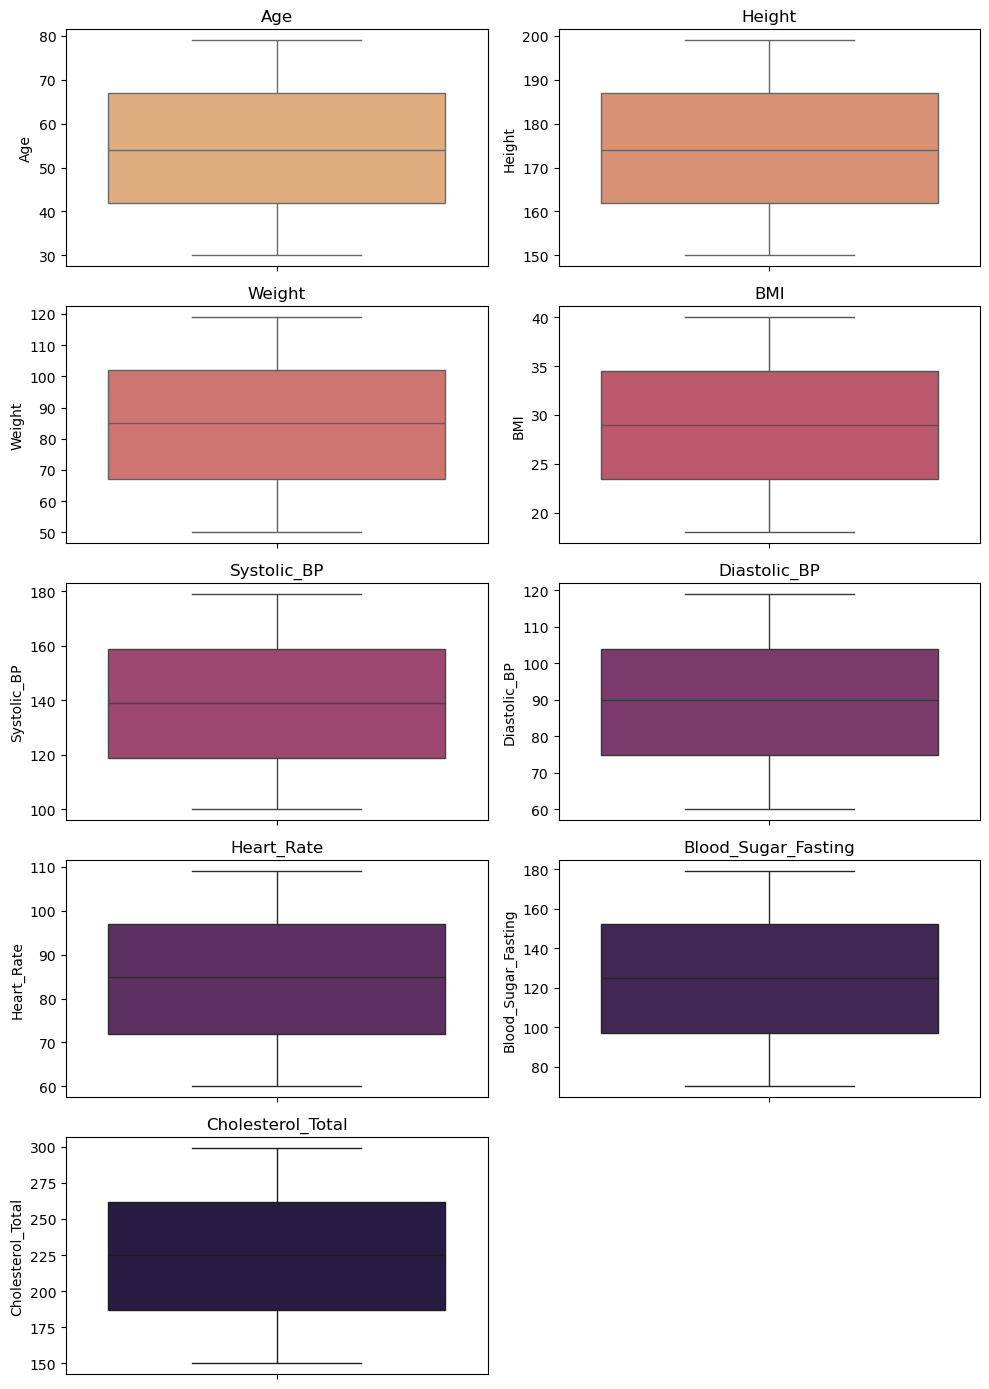

In [82]:
fig , axes = plt.subplots(5,2, figsize=(10,14))
col = ["Age", "Height", "Weight", "BMI", "Systolic_BP", "Diastolic_BP", "Heart_Rate", "Blood_Sugar_Fasting", "Cholesterol_Total"]
colors = ["#f0ac71", "#e98a66", "#de6661", "#cb4a63", "#aa3a6e", "#863170", "#63286a","#431f5c","#241549"]
axes = axes.flatten()

for i, col in enumerate(col):
    sns.boxplot(df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(col)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("outputs/univar_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

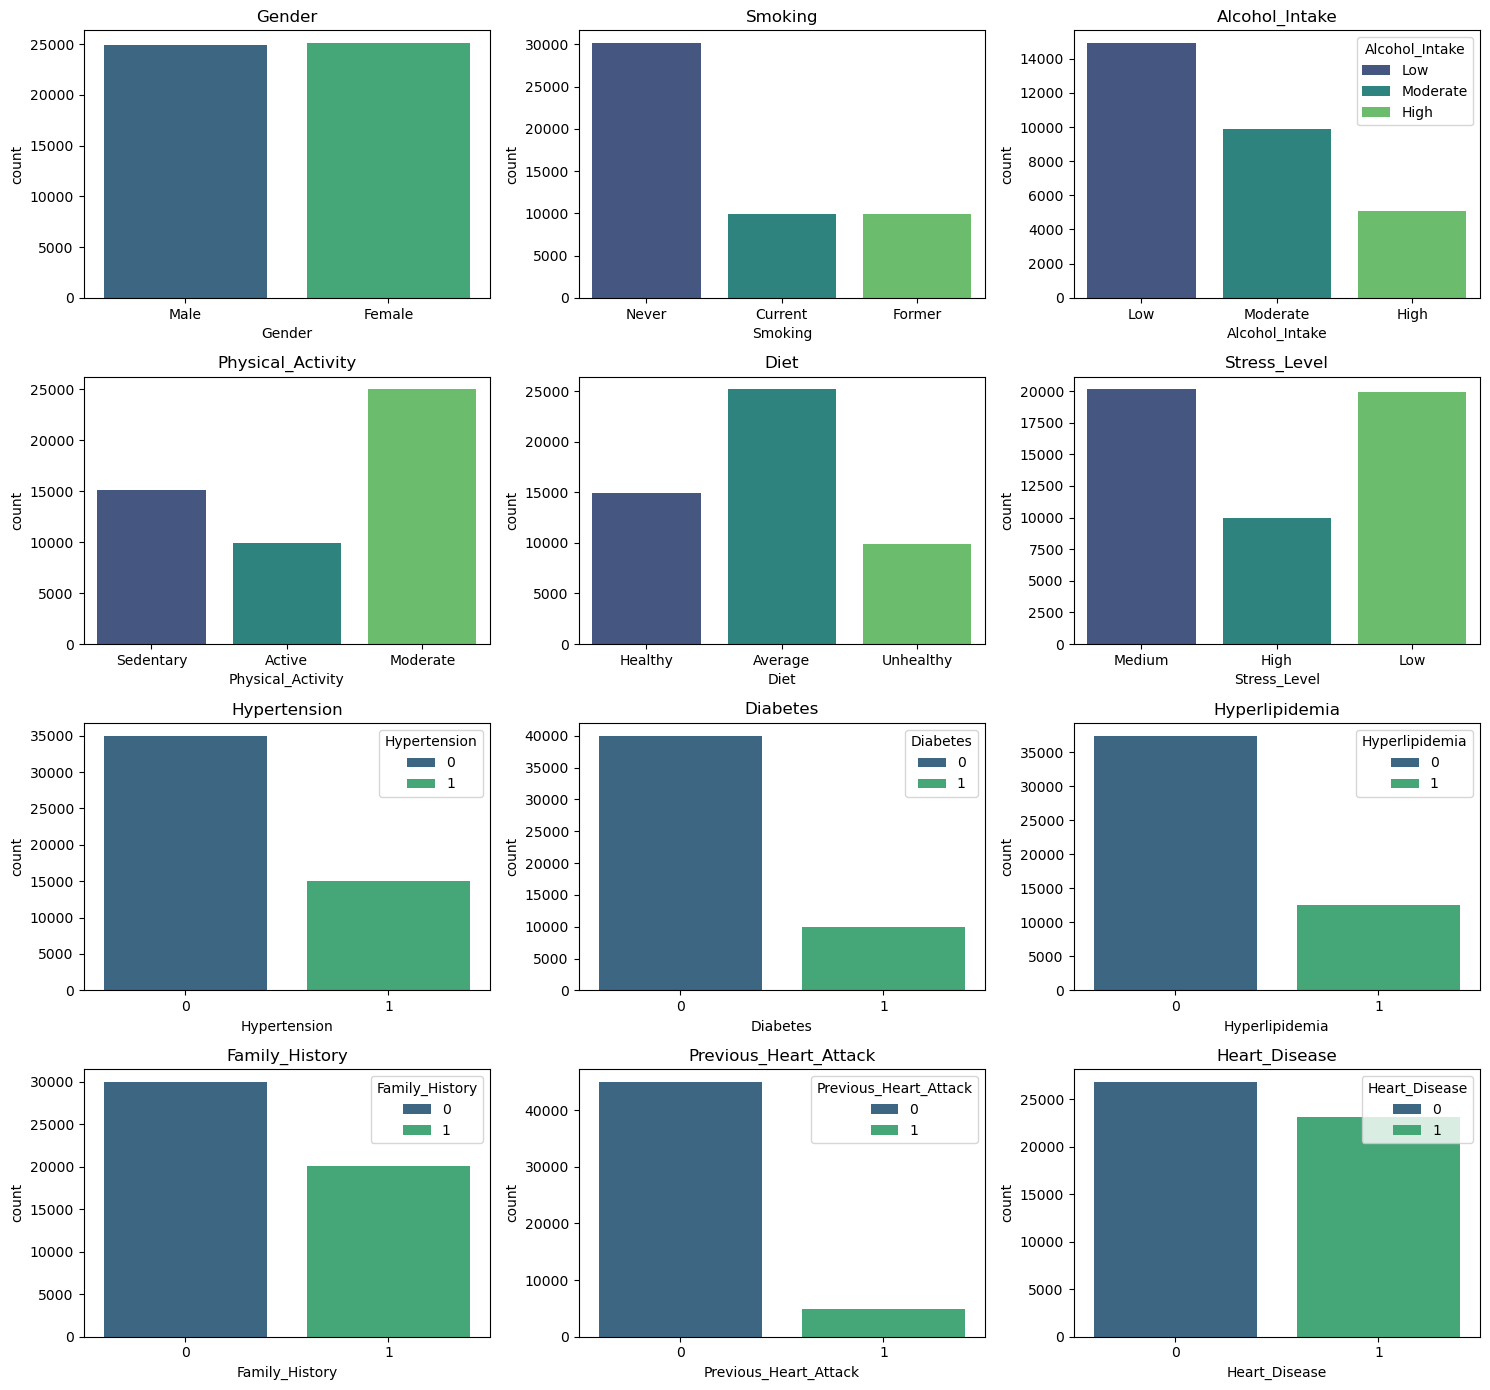

In [83]:
fig , axes = plt.subplots(4,3, figsize=(15,14))
axes = axes.flatten()

for i, col in enumerate(categ_cols):
    sns.countplot(x=df[col], hue=df[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col)


plt.tight_layout()
plt.savefig("outputs/univar_barcharts.png", dpi=150, bbox_inches="tight")
plt.show()

### Outlier detection

In [84]:
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    up = q3 + 1.5 * iqr
    df[f"{col} outliers"] = (df[col].values < low) | (df[col].values > up)

df.filter(like=" outliers").sum()

Age outliers                    0
Weight outliers                 0
Height outliers                 0
BMI outliers                    0
Systolic_BP outliers            0
Diastolic_BP outliers           0
Heart_Rate outliers             0
Blood_Sugar_Fasting outliers    0
Cholesterol_Total outliers      0
dtype: int64

    Numeric Features & Outliers:
        All columns show normal distribution. Using the IQR method all columns showed 0 outliers. That means all measures of center and spread are represntative for this dataset.

    Categorical Features:
        Most lifesytle and behaivuoral factors are dominated by one category, e.g 60% of patients are non-smokers and roughly 50% of pateints showed low alchohol intake. Majority of diagnoses show that most patients do not suffer from the listed disease. Also around. 90% of patients have never experinced heart attacks before.


### Bivariate Analysis

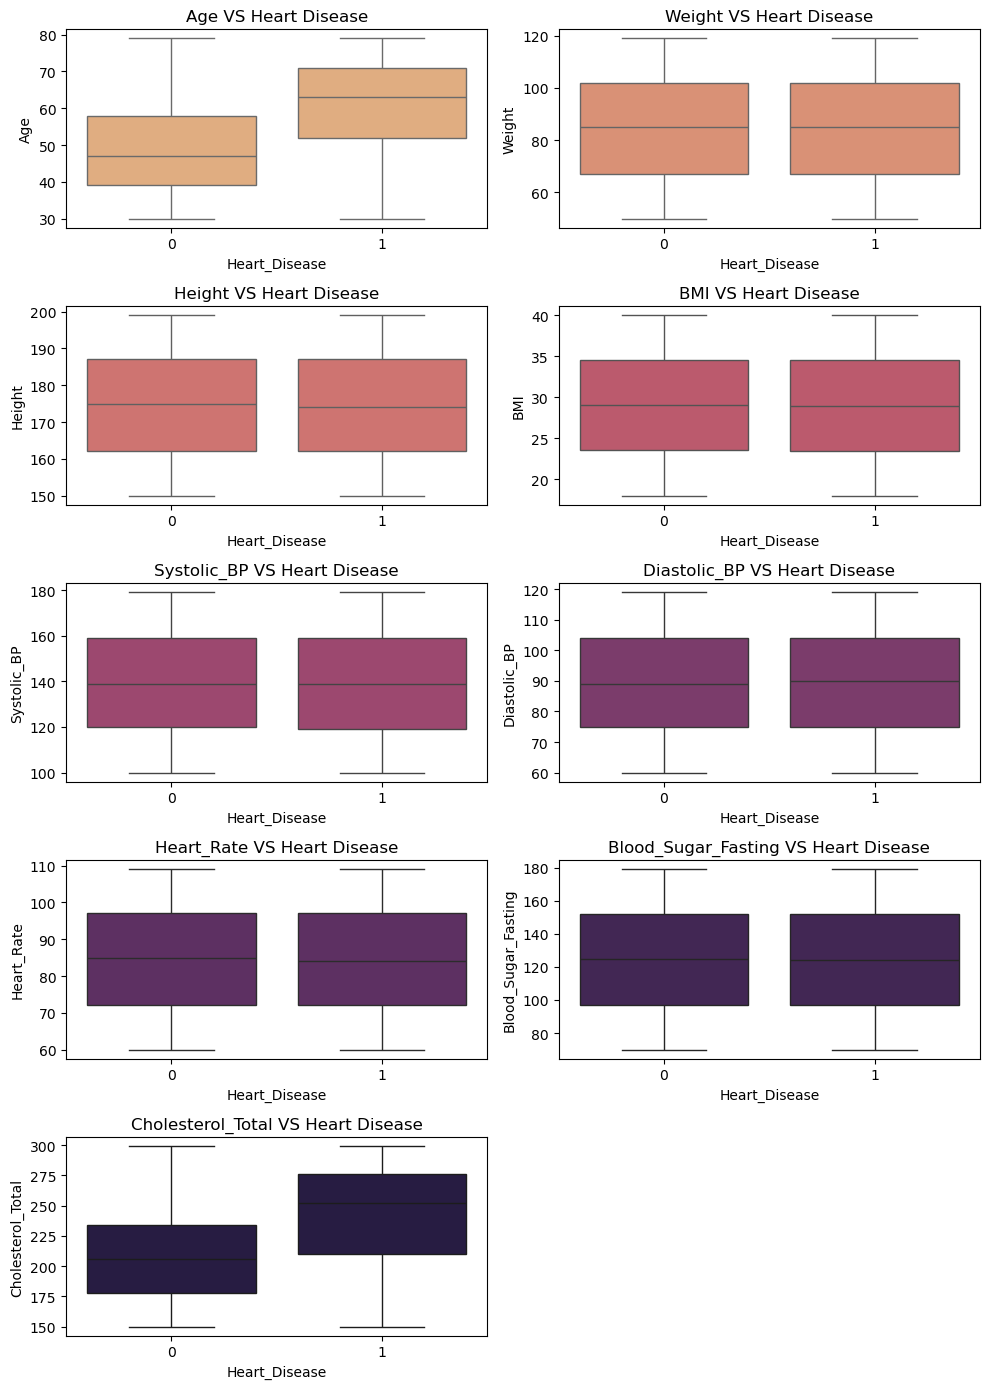

In [85]:
fig , axes = plt.subplots(5,2, figsize=(10,14))
axes = axes.flatten()
colors = ["#f0ac71", "#e98a66", "#de6661", "#cb4a63", "#aa3a6e", "#863170", "#63286a","#431f5c","#241549"]

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df["Heart_Disease"], y=df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(f"{col} VS Heart Disease")

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("outputs/bivar_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


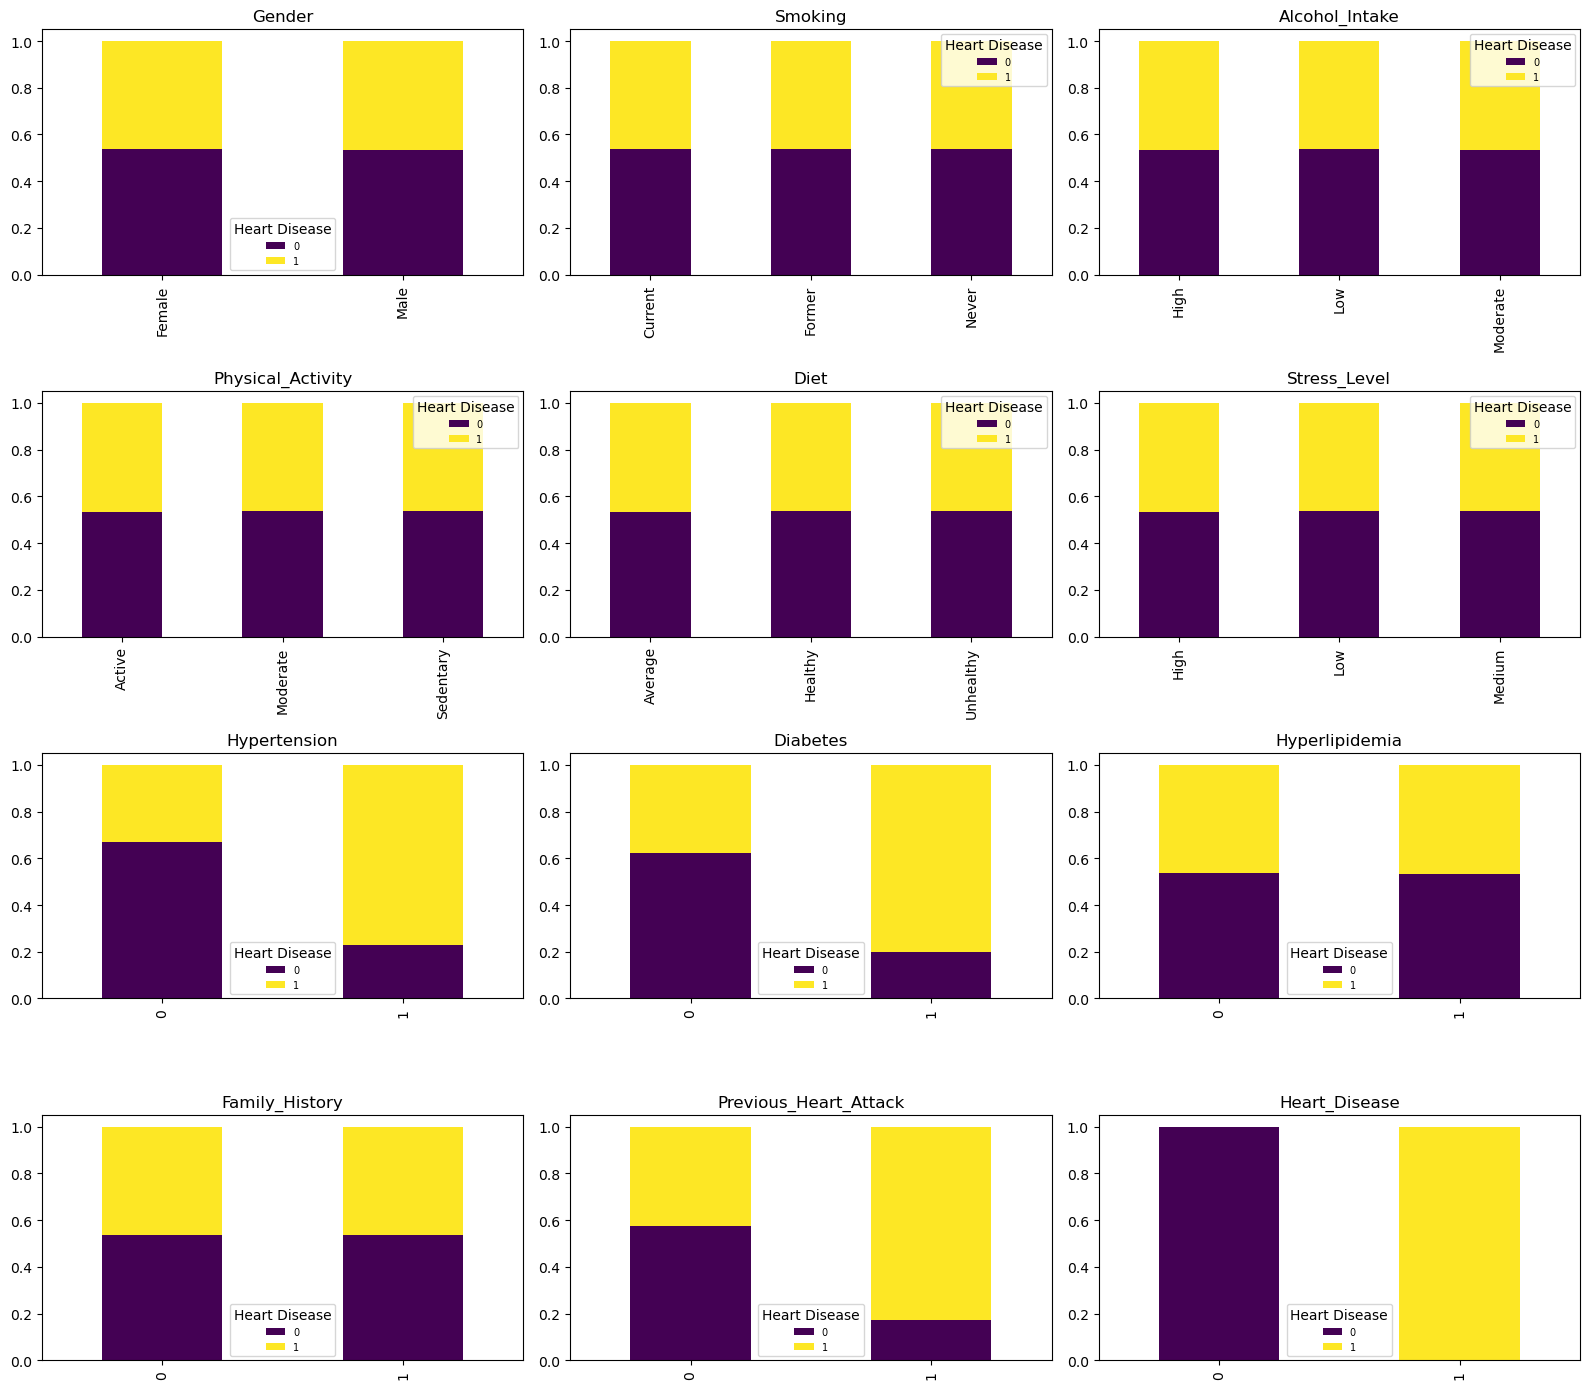

In [86]:
fig , axes = plt.subplots(4,3, figsize=(16,14))
axes = axes.flatten()
for i, col in enumerate(categ_cols):
    pd.crosstab(df[col], df["Heart_Disease"], normalize='index').plot(kind='bar', stacked='True', ax=axes[i], colormap='viridis')
    axes[i].set_title(col)
    axes[i].legend(title="Heart Disease", fontsize=7)
    axes[i].set_xlabel("")


plt.tight_layout()
plt.savefig("outputs/bivar_stackedbarcharts.png", dpi=150, bbox_inches="tight")
plt.show()

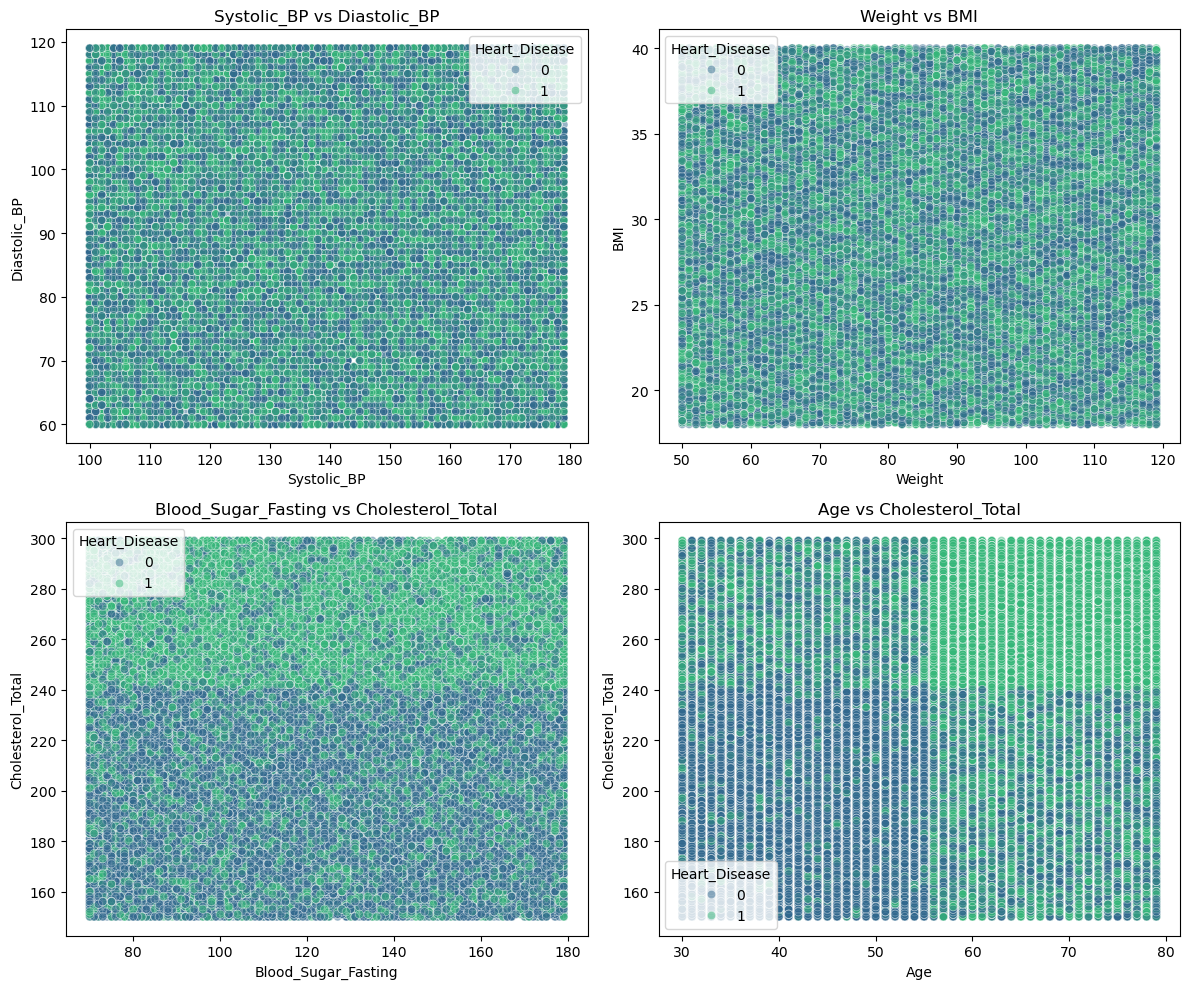

In [87]:
pairs = [
    ("Systolic_BP", "Diastolic_BP"),
    ("Weight", "BMI"),              # remove if you already dropped Weight/Height
    ("Blood_Sugar_Fasting", "Cholesterol_Total"),
    ("Age", "Cholesterol_Total")     # optional 4th pair to fill the grid evenly
]
fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.flatten()

for i,(x_col, y_col) in enumerate (pairs):
    sns.scatterplot(data = df, x=x_col, y=y_col, hue="Heart_Disease", palette='viridis', alpha=0.5, ax=axes[i])
    axes[i].set_title(f"{x_col} vs {y_col}")

plt.tight_layout()
plt.savefig("outputs/bivar_scatterplots.png", dpi=150, bbox_inches="tight")
plt.show()

### Correlation Heatmap

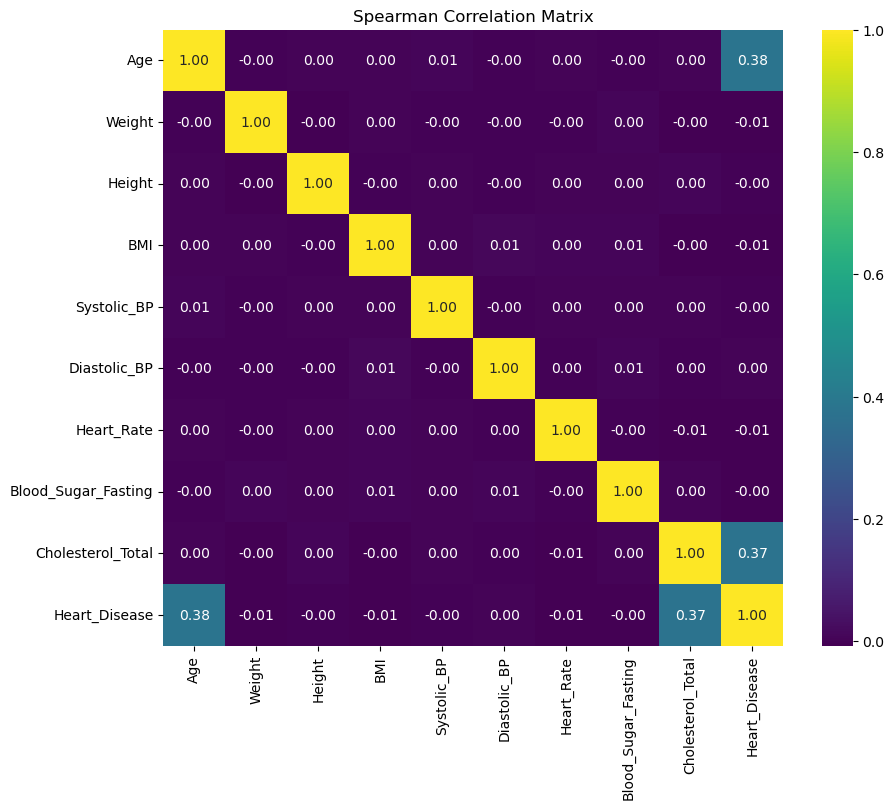

In [88]:
corr_cols= numeric_cols +["Heart_Disease"]
corr = df[corr_cols].corr(method="spearman")
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="viridis", annot=True, fmt=".2f")
plt.title("Spearman Correlation Matrix")
plt.savefig("outputs/bivar_correlationheatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

### Basic Feature Cleanup

In [89]:
df["Alcohol_Intake"] = df["Alcohol_Intake"].fillna("unknown")

    Numeric features vs Target:
        Comparing distributions by disease status revealed a clear seperation in Age and Colestrol_Total. Patients with heart disease appear to be older with higher colestrol levels in average.

    Categorical features vs Target:
        Disease rates variated noticeably by diagnoses diseases. For instance, patients positive for Diabetes, Hypertention and Previous heart Attacks showed a heart disease rate of almost 80% compored to 40% for those without the diagnoses.

    Scatter plots:
        Plotting Blood_Sugar_Fasting vs Cholesterol_Total, colored by heart disease, demonstrated that patients with higher colestrol levels regardless of their blood sugar levels had higher numbers of heart disease. Age vs Cholesterol_Total showed a visible seperation with majority disease positive patients clustering toward higher values on both axes.
    
    Correlation Heatmap:
        The correlation heatmap confirms that Age and Colestrol Total are slightly correlated with heart disease were mostly postive heart disease.

### EDA - Key Takeaways

    - The target variable is well balanced (53.7% / 46.3%) which requires no class-weighting or resampling in later stages.
    - Age, Colestrol_Total, Diabetes, Hypertensionand Previous_Heart_Attaks show the clearest relationship with Heart_Disease and are likely strong predictors.
    - Gender showed weak seperation by target and may contribute less to the model.
    Weight and Height are redundant with BMI and will be dropped during feature engineering.
    -During EDA and descriptive statistics, Alchohol intake  was found to have 40% missing values which were handled by labeling them as "unknown" category.

    With EDA complete, the next step is to define the supervised learning problem, train/validation/test split the data to train a baseline classifer.

## Supervised Baseline

    Since the target vairable is categorical, Logistic Regression will be used to define the baseline model after train/test splitting, one-hot encoding and scaling the data.

In [90]:
x = df.drop(columns=["Heart_Disease"])
y = df["Heart_Disease"]

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify = y)

In [92]:
#one-hot encoding
x_train_encoded = pd.get_dummies(x_train, drop_first=True)
x_test_encoded = pd.get_dummies(x_test, drop_first=True)

#alignhing columns -test set might not have all categories in train
x_train_encoded, x_test_encoded = x_train_encoded.align(x_test_encoded, join='left', axis=1, fill_value=0)

#scaling columns
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_encoded)
x_test_scaled = scaler.transform(x_test_encoded)

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(x_train_scaled, y_train)

y_pred = baseline.predict(x_test_scaled)


### Baseline Performance

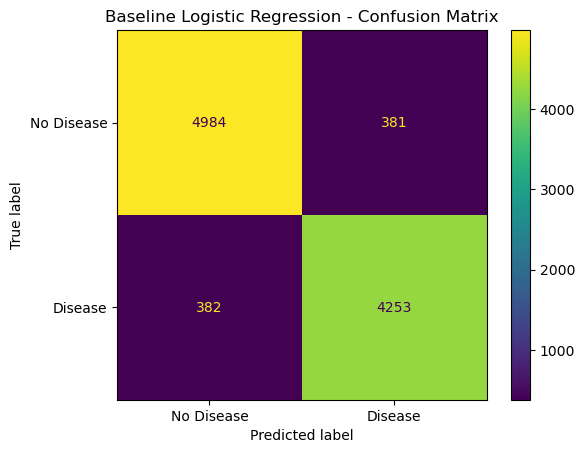

In [94]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cfmx_lr = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cfmx_lr, display_labels=["No Disease", "Disease"])
disp.plot(cmap='viridis')
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

In [95]:
print("Baseline Logistic Regression Performance")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("\nFull classification report: \n", classification_report(y_test, y_pred))

Baseline Logistic Regression Performance
Accuracy:  0.9237
Precision:  0.9177816141562365
Recall:  0.9175836030204962
F1 Score:  0.9176825979070018

Full classification report: 
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      5365
           1       0.92      0.92      0.92      4635

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



### Baseline - Key Takeaways

    The model correctly classifies 92% of the test patients. Precision - of all patients the model predicted having a heart disease, 92% did. Recall- of all patients who had a heart disease, the model correctly caught 92% of them.

    These results verify that the features carry predictive signal for heart disease given a class balance of 53%/47%. Both (disease/no disease) classes perform similarly near perfect without any bias towards one class.

    The model only failed to predict about 8% of those who in fact had the disease. Similarly it unsuccessfully labeled around 8% of those who were negative for heart disease as positve. 

    The unusual overall high performance of the model may reflect the synthetic nature of the dataset, which likely encodes cleaner feature-target relationships than real-world clinical data would.
    

## Second Classifier

In [96]:
from sklearn.ensemble import RandomForestClassifier

rfst = RandomForestClassifier(n_estimators=200, random_state=42)
rfst.fit(x_train_scaled, y_train)

y_pred_rfst = rfst.predict(x_test_scaled)

    To compare against the Logistic Regression baseline model, a Random Forest Classifier was trained using the same train/test split and preprocessing pipeline (scaled numeric columns and one-hot encoded categorical variables). While Logistic Regression assumes a linear relationship betweeen features and the target, Random Forest offers a useful point of comparison for this data set in contrast.

## Cross Validation

In [97]:
from sklearn.model_selection import cross_val_score

cv_score_lr = cross_val_score(baseline, x_train_scaled, y_train, cv=5, scoring="accuracy")
cv_score_rfst = cross_val_score(rfst, x_train_scaled, y_train, cv=5, scoring="accuracy")

print("Logistic Regression Cross-validation Accuracy: ", cv_score_lr.mean(),"±", cv_score_lr.std())
print("Random Forest Cross-validation Accuracy: ", cv_score_rfst.mean(),"±", cv_score_rfst.std())

Logistic Regression Cross-validation Accuracy:  0.9249 ± 0.0017965244223221686
Random Forest Cross-validation Accuracy:  1.0 ± 0.0


    For a more reliable performance evaluation, 5-fold cross validation was performed on the training data fro both models.
    Both models showed consistent results across folds with low variance with Random Forest being slightly higher which may indicate overfitting of certain subsets of the dataset.
    

## Evaluation

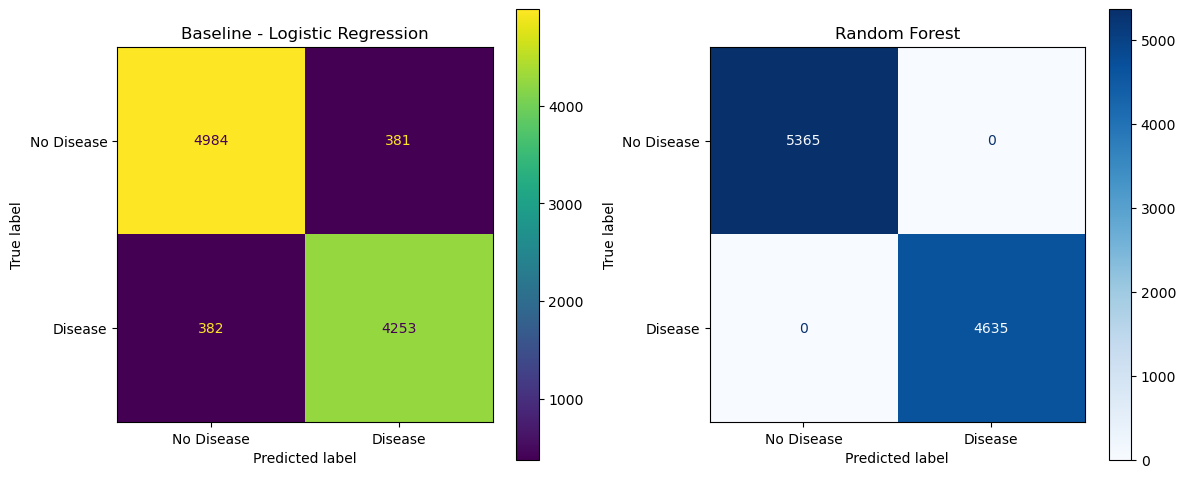

In [98]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
ConfusionMatrixDisplay(cfmx_lr, display_labels=["No Disease", "Disease"]).plot(ax=axes[0],cmap='viridis')
axes[0].set_title("Baseline - Logistic Regression")


cfmx_rfst = confusion_matrix(y_test, y_pred_rfst)
ConfusionMatrixDisplay(cfmx_rfst, display_labels=["No Disease", "Disease"]).plot(ax=axes[1],cmap='Blues')
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.savefig("outputs/confusionmatrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [99]:
y_proba_lr = baseline.predict_proba(x_test_scaled)[:,1]
y_proba_rfst = rfst.predict_proba(x_test_scaled)[:,1]

comparison = pd.DataFrame({
    "Logistic Regression":[
         accuracy_score(y_test, y_pred),
         precision_score(y_test, y_pred),
         recall_score(y_test, y_pred),
         f1_score(y_test, y_pred),
         roc_auc_score(y_test, y_proba_lr)
    ],
    "Random Forest":[
         accuracy_score(y_test, y_pred_rfst),
         precision_score(y_test, y_pred_rfst),
         recall_score(y_test, y_pred_rfst),
         f1_score(y_test, y_pred_rfst),
         roc_auc_score(y_test, y_proba_rfst)
    ]
}, index =["Accuracy", "Precision", "Recall","F1","ROC-AUC"])
print(comparison)

           Logistic Regression  Random Forest
Accuracy              0.923700            1.0
Precision             0.917782            1.0
Recall                0.917584            1.0
F1                    0.917683            1.0
ROC-AUC               0.982202            1.0


The Confusion Matrices show each model's prediction breakdown on the test set

    Logistic Regression
        True Negatives: 4984 correctly predicted no disease
        False Positives: 381 predicted to have the disease, but were healthy
        Flase Negatives: 382 predicted healthy, but had the disease
        True Positives: 4256 correctly predicted to have the disease

    Random Forest
        True Negatives: 5365 correctly predicted no disease
        False Positives: 0 predicted to have the disease, but were healthy
        Flase Negatives: 0 predicted healthy, but had the disease
        True Positives: 4635 correctly predicted to have the disease

    In plain language false positives are healthy patients who were incorrectly flagged as having a heart disease, but false negatives are patients with heart disease who the model missed and flagged as healthy -  more clinically concerning error. Random Forest model succesfully avoided both scenarios and correctly flagged each patient.

### Model comparison & Evaluation - Key Takeaways

    Random Forest  perfect baseline is revisited critically in the feature engineering section below, where feature importance analysis reveals this is likely due to the synthetic dataset's generation process rather than genuine predictive superiority.
    
    Both models were evaluated using the same metrics, preprocessing and cross-validation, to ensure fairness and consitent comparison.

## Feature Engineering

In [100]:
# droppig redundant columns
df_fe = df.drop(columns=["Weight","Height"])

#feature extraction
df_fe["Pulse_Pressure"] = df_fe["Systolic_BP"] - df_fe["Diastolic_BP"]

In [101]:
x = df_fe.drop(columns=["Heart_Disease"])
y = df_fe["Heart_Disease"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify = y)

In [102]:
num_feat = x.select_dtypes(include=["int64","float64"]).columns.tolist()
binary = [col for col in num_feat if x[col].nunique() <= 2]
num_feat = [col for col in num_feat if col not in binary]

categ_feat = x.select_dtypes(include=['object']).columns.tolist()

print("Numeric:", num_feat)
print("Binary Flags:", binary)
print("Categorical:", categ_feat)

Numeric: ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total', 'Pulse_Pressure']
Binary Flags: ['Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack']
Categorical: ['Gender', 'Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level']


In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

pre = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_feat),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categ_feat),
    ("bin","passthrough", binary)
])

lr_pipe = Pipeline(steps =[
    ("preprocessor", pre),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipe = Pipeline(steps =[
    ("preprocessor", pre),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])

In [104]:
lr_pipe.fit(x_train, y_train)
rf_pipe.fit(x_train, y_train)

y_pred_lr_pipe = lr_pipe.predict(x_test)
y_pred_rf_pipe = rf_pipe.predict(x_test)

print("Logistic Regression (Pipeline) Accuracy:", accuracy_score(y_test, y_pred_lr_pipe))
print("Random Forest (Pipeline) Accuracy:", accuracy_score(y_test, y_pred_rf_pipe))

Logistic Regression (Pipeline) Accuracy: 0.9237
Random Forest (Pipeline) Accuracy: 1.0


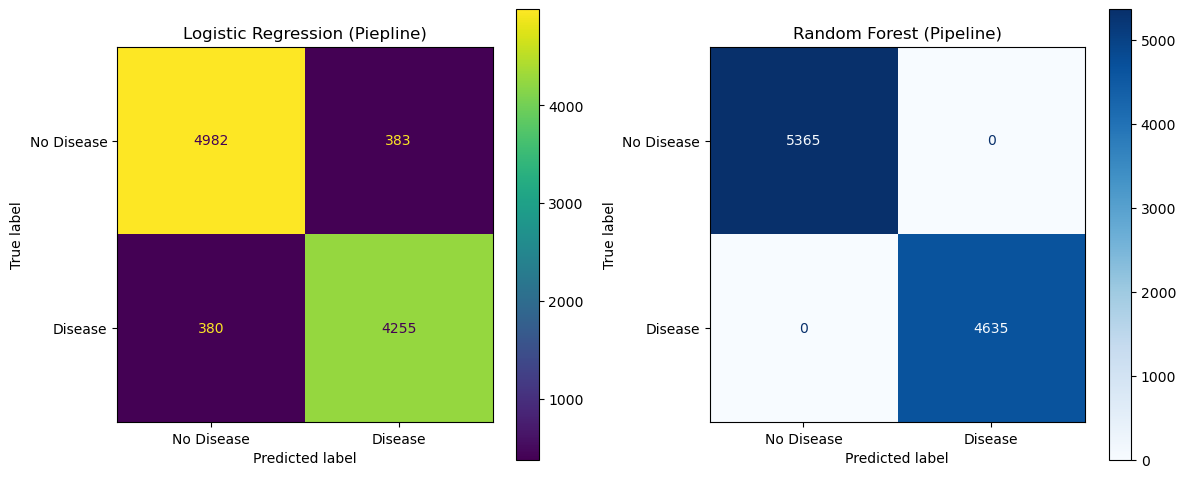

In [105]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
cfmx_lr_pipe = confusion_matrix(y_test, y_pred_lr_pipe)
ConfusionMatrixDisplay(cfmx_lr_pipe, display_labels=["No Disease", "Disease"]).plot(ax=axes[0],cmap='viridis')
axes[0].set_title("Logistic Regression (Piepline)")


cfmx_rf_pipe = confusion_matrix(y_test, y_pred_rf_pipe)
ConfusionMatrixDisplay(cfmx_rf_pipe, display_labels=["No Disease", "Disease"]).plot(ax=axes[1],cmap='Blues')
axes[1].set_title("Random Forest (Pipeline)")

plt.tight_layout()
plt.savefig("outputs/confusionmatrix_pipeline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

    The Confusion Matrices show each model's prediction breakdown on the test set

    Logistic Regression
        True Negatives: 4984 correctly predicted no disease
        False Positives: 383 predicted to have the disease, but were healthy
        Flase Negatives: 380 predicted healthy, but had the disease
        True Positives: 4255 correctly predicted to have the disease

    Random Forest
        True Negatives: 5365 correctly predicted no disease
        False Positives: 0 predicted to have the disease, but were healthy
        Flase Negatives: 0 predicted healthy, but had the disease
        True Positives: 4635 correctly predicted to have the disease

      Random Forest avoided both error types entirely achieving perfect accuracy, precision, recall, F1 on the test set - identical results before and after feature engineering.


In [106]:
y_proba_lr_pipe = lr_pipe.predict_proba(x_test)[:,1]
y_proba_rfst_pipe = rf_pipe.predict_proba(x_test)[:,1]

comparison_pipe = pd.DataFrame({
    "Logistic Regression":[
         accuracy_score(y_test, y_pred_lr_pipe),
         precision_score(y_test, y_pred_lr_pipe),
         recall_score(y_test, y_pred_lr_pipe),
         f1_score(y_test, y_pred_lr_pipe),
         roc_auc_score(y_test, y_proba_lr_pipe)
    ],
    "Random Forest":[
         accuracy_score(y_test, y_pred_rf_pipe),
         precision_score(y_test, y_pred_rf_pipe),
         recall_score(y_test, y_pred_rf_pipe),
         f1_score(y_test, y_pred_rf_pipe),
         roc_auc_score(y_test, y_proba_rfst_pipe)
    ]
}, index =["Accuracy", "Precision", "Recall","F1","ROC-AUC"])
print(comparison_pipe)

           Logistic Regression  Random Forest
Accuracy              0.923700            1.0
Precision             0.917421            1.0
Recall                0.918015            1.0
F1                    0.917718            1.0
ROC-AUC               0.982211            1.0


In [107]:
importances = rf_pipe.named_steps["classifier"].feature_importances_
feature_names = (num_feat + 
    list(rf_pipe.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categ_feat)) + 
    binary)

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(10))

Age                      0.255756
Cholesterol_Total        0.241641
Hypertension             0.204430
Diabetes                 0.150098
Previous_Heart_Attack    0.078530
BMI                      0.009776
Pulse_Pressure           0.008936
Blood_Sugar_Fasting      0.008899
Heart_Rate               0.008297
Systolic_BP              0.008264
dtype: float64


### Featur Engineering - Key Takeaways
    
Two feature engineering decisions were made:
        1- Weight and Heigtht were dropped; redundunt with BMI wich captures the body-composition information
        2- Pulse_Pressure was extracted from the difference betwee Systolic and Diastolic blood pressure. It is a clinical measure of arterial stiffness.


    To ensure model reusability and full preprocessing a Scikit-learn Pipline was built combining the classifiers, and ColumnTransformer that scales numeric features, one-hot encodes categorical features and passes binary columns through.

    Both Pipelines were compared against the baseline  to check wether feature engineering improver=d their performances.

    This perfect score should not be read as evidence of a better model.
    Feature importance analysis showed that just five feature (Age,Cholesterol_Total, Hypertension, Diabetes, Previous_Heart_Attack) account for roughly 93% of Random Forest's decisions. This strongly suggests the synthetic dataset was generated using a deterministic rule based primarily on these variables. Random Forest, was able to reverse engineer this rule and identify the pattern. Logistic Regression  could not fully capture it resulting in a more realistic reflection (92% accuracy).

    The fact tat Random Forest's confusion matrix stayed unchanged before and after feature engineering further supports that none of the top five deterministic features that drive its decisions have undergone cny changes.


    Both models were evaluated using the same metrics, given the analysis, Logistic Regression is considered the more trustworthy model for this dataset. Since  its performance is not attributable to reconstructing a synthetic generation rule, Random Forest's result, while numerically higher is an artifact of the dataset rather than a meaningful modeling insight.


In [60]:
##outputs
import os
for file in sorted(os.listdir("outputs")):
    print(file)

bivar_boxplots.png
bivar_correlationheatmaps.png
bivar_scatterplots.png
bivar_stackedbarcharts.png
confusionmatrix_comparison.png
univar_barcharts.png
univar_boxplots.png
univar_histograms.png


### Fianl Results Summary

**Recommended model:** Logistic Regression - logistic regression's 92% accuracy is more reliablle and generalizable result.

**Top predictive features:** Age, Cholestrol_Total, Hypertension, Diabetes, and Previous_Heart_Attack account for roughlt 93% of Random Forest's decision-making and showing the clearest seperation by target class throughout this analysis.

**Key Limitation:** this is a synthetic dataset, and a perfect classifier is not a realistic outcome on real clinical data - any real-world appliication would require validation on genuine patient records.

This concludes the analysis: data preperation, EDA, baseline modeling, model comparison and evaluation, and feature engineering with a reusable pipeline were each completed and documented.